In [1]:
# Cell 1: Install & Verify Dependencies
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("scikit-learn")
install("matplotlib")
install("seaborn")
install("PyWavelets")   # for teammate (Member 3) compatibility

print("All packages ready.")

All packages ready.


In [2]:
# Cell 2: Imports

import os, tarfile, shutil, json, random, time, zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

PyTorch 2.10.0+cu128 | CUDA available: True
Using device: cuda


In [3]:
# Cell 3: Reproducibility Seed
# Must match Member 1 exactly (seed=42) for fair comparison.

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Global seed set to {SEED}.")

Global seed set to 42.


In [4]:
# Cell 4: Path Configuration
# Mirrors Member 1's layout exactly so the dataset is shared on the same machine.
# Member 2's outputs are saved to /content/outputs_m2/ to avoid overwriting Member 1.

CONTENT       = Path("/content")
TAR_TRAIN     = CONTENT / "train.tar"
TAR_VAL       = CONTENT / "val.tar"
TAR_TEST      = CONTENT / "test.tar"

EXTRACT_ROOT  = CONTENT / "miniimagenet_raw"
DATASET_ROOT  = CONTENT / "miniimagenet"

OUTPUT_DIR    = CONTENT / "outputs_m2"
CKPT_PATH     = OUTPUT_DIR / "mobilenetv2_best.pth"
ZIP_PATH      = CONTENT / "member2_submission.zip"

# Path to Member 1's baseline JSON (used for comparison later)
M1_BASELINE   = CONTENT / "outputs" / "baseline_results.json"
M1_PER_CLASS  = CONTENT / "outputs" / "per_class_accuracy.json"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [TAR_TRAIN, TAR_VAL, TAR_TEST]:
    status = "✓ found" if p.exists() else "✗ MISSING"
    print(f"  {status}: {p}")

  ✓ found: /content/train.tar
  ✓ found: /content/val.tar
  ✓ found: /content/test.tar


In [5]:
# Cell 5: Extract Tar Files
# Skips if already extracted by Member 1 — safe to re-run.

def extract_tar(tar_path: Path, dest: Path):
    dest.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {tar_path.name} → {dest} ...", end=" ", flush=True)
    with tarfile.open(tar_path) as tf:
        tf.extractall(path=dest)
    print("done.")

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:
    dest = EXTRACT_ROOT / split
    if not dest.exists():
        extract_tar(TAR_TRAIN if split == "train" else (TAR_VAL if split == "val" else TAR_TEST), dest)
    else:
        print(f"{split}/ already extracted — skipping.")

Extracting train.tar → /content/miniimagenet_raw/train ... 

/tmp/ipykernel_5444/3026253078.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=dest)


done.
Extracting val.tar → /content/miniimagenet_raw/val ... done.
Extracting test.tar → /content/miniimagenet_raw/test ... done.


In [6]:
# Cell 6: Inspect Raw Extraction Structure (same as Member 1)

def list_top(path: Path, depth=2):
    for root, dirs, files in os.walk(path):
        level = len(Path(root).relative_to(path).parts)
        if level > depth:
            dirs.clear()
            continue
        indent = "  " * level
        print(f"{indent}{Path(root).name}/  [{len(files)} files]")

for split in ["train", "val", "test"]:
    print(f"\n=== {split} ===")
    list_top(EXTRACT_ROOT / split, depth=3)


=== train ===
train/  [0 files]
  train/  [0 files]
    n04443257/  [600 files]
    n02113712/  [600 files]
    n01532829/  [600 files]
    n03400231/  [600 files]
    n04389033/  [600 files]
    n13054560/  [600 files]
    n07747607/  [600 files]
    n02108915/  [600 files]
    n04251144/  [600 files]
    n04509417/  [600 files]
    n02108089/  [600 files]
    n04596742/  [600 files]
    n02747177/  [600 files]
    n04243546/  [600 files]
    n02074367/  [600 files]
    n02091831/  [600 files]
    n02165456/  [600 files]
    n03838899/  [600 files]
    n02457408/  [600 files]
    n03017168/  [600 files]
    n07584110/  [600 files]
    n01770081/  [600 files]
    n02823428/  [600 files]
    n02089867/  [600 files]
    n04612504/  [600 files]
    n01558993/  [600 files]
    n02108551/  [600 files]
    n04604644/  [600 files]
    n03047690/  [600 files]
    n01843383/  [600 files]
    n09246464/  [600 files]
    n04067472/  [600 files]
    n02966193/  [600 files]
    n13133613/  [600 fi

In [7]:
# Cell 7: Normalise into Standard ImageFolder Layout
# Identical to Member 1. If Member 1 already built the dataset, this is a no-op.

def find_class_dirs(split_root: Path, split_name: str):
    """Auto-detect and return list of (class_name, src_path) tuples."""
    candidates = [
        split_root,
        split_root / "images",
        split_root / split_name,
    ]
    for candidate in candidates:
        if candidate.exists():
            subdirs = [d for d in candidate.iterdir() if d.is_dir()]
            if subdirs:
                has_images = any(
                    list(d.glob("*.jpg")) or list(d.glob("*.JPEG")) or list(d.glob("*.png"))
                    for d in subdirs[:3]
                )
                if has_images:
                    print(f"  Class root found: {candidate}  ({len(subdirs)} classes)")
                    return [(d.name, d) for d in subdirs]
    raise RuntimeError(f"Cannot find class directories under {split_root}.")


def build_dataset(extract_root: Path, dataset_root: Path):
    if dataset_root.exists():
        print(f"{dataset_root} already exists — skipping rebuild.")
        return
    for split in ["train", "val", "test"]:
        split_src = extract_root / split
        split_dst = dataset_root / split
        class_dirs = find_class_dirs(split_src, split)
        print(f"\n{split}: {len(class_dirs)} classes")
        for cls_name, src_dir in class_dirs:
            dst_dir = split_dst / cls_name
            dst_dir.mkdir(parents=True, exist_ok=True)
            images = [f for f in src_dir.iterdir()
                      if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
            for img in images:
                shutil.copy2(img, dst_dir / img.name)
        n_images = sum(len(list((split_dst / c).glob("*"))) for c in os.listdir(split_dst))
        print(f"  → {n_images} images in {split_dst}")
    print("\nDataset build complete.")

build_dataset(EXTRACT_ROOT, DATASET_ROOT)

  Class root found: /content/miniimagenet_raw/train/train  (64 classes)

train: 64 classes
  → 38400 images in /content/miniimagenet/train
  Class root found: /content/miniimagenet_raw/val/val  (16 classes)

val: 16 classes
  → 9600 images in /content/miniimagenet/val
  Class root found: /content/miniimagenet_raw/test/test  (20 classes)

test: 20 classes
  → 12000 images in /content/miniimagenet/test

Dataset build complete.


In [8]:
# Cell 8: Dataset Statistics

for split in ["train", "val", "test"]:
    split_path = DATASET_ROOT / split
    classes = sorted(os.listdir(split_path))
    total = sum(len(list((split_path / c).glob("*"))) for c in classes)
    print(f"{split:5s}: {len(classes)} classes, {total} images "
          f"(avg {total/len(classes):.1f} per class)")

CLASS_NAMES = sorted(os.listdir(DATASET_ROOT / "train"))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nTotal training classes: {NUM_CLASSES}")

train: 64 classes, 38400 images (avg 600.0 per class)
val  : 16 classes, 9600 images (avg 600.0 per class)
test : 20 classes, 12000 images (avg 600.0 per class)

Total training classes: 64


In [9]:
# Cell 9: Hyperparameters & Image Transforms
# MUST match Member 1 exactly for a fair comparison.

IMG_SIZE     = 96        # same as Member 1
CROP_TRAIN   = 84        # same as Member 1

BATCH_SIZE   = 64
NUM_EPOCHS   = 30
LR           = 1e-3
LR_STEP      = 10
LR_GAMMA     = 0.1
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2

# ImageNet normalisation — identical to Member 1
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(CROP_TRAIN, padding=4),
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transforms defined (identical to Member 1).")
print(f"  Train input: random crop → {CROP_TRAIN}px → resize to {IMG_SIZE}px")
print(f"  Eval  input: resize to {IMG_SIZE}px")

Transforms defined (identical to Member 1).
  Train input: random crop → 84px → resize to 96px
  Eval  input: resize to 96px


In [10]:
# Cell 10: Build PyTorch Datasets & DataLoaders
# Identical to Member 1 — same seed, same 90/10 stratified split.
#
# Dataset split note (Mini-ImageNet by design has NON-OVERLAPPING classes):
#   train/ → 64 classes  ← model is fine-tuned on these
#   val/   → 16 classes  ← unseen classes (different from train)
#   test/  → 20 classes  ← unseen classes (different from train)
#
# Strategy (same as Member 1):
#   - Carve 10% from train/ as our internal val set (same 64 classes as training)
#   - This internal val_loader is what we use for ALL comparisons (76.48% baseline)
#   - The original test/ split loader is defined but its accuracy is not meaningful
#     because it contains 20 completely different classes the model was never trained on.

full_train_dataset = datasets.ImageFolder(
    DATASET_ROOT / "train", transform=train_transform
)

label_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_train_dataset.samples):
    label_to_indices[label].append(idx)

train_indices, val_indices = [], []
for label, indices in label_to_indices.items():
    random.shuffle(indices)
    cut = max(1, int(0.9 * len(indices)))
    train_indices.extend(indices[:cut])
    val_indices.extend(indices[cut:])

full_train_eval = datasets.ImageFolder(
    DATASET_ROOT / "train", transform=eval_transform
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset   = Subset(full_train_eval,   val_indices)

# Original test split (20 unseen classes — defined for completeness, not used for comparison)
orig_test_dataset = datasets.ImageFolder(
    DATASET_ROOT / "test", transform=eval_transform
)

train_loader = DataLoader(train_dataset,      batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,        batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(orig_test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = full_train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Train subset : {len(train_dataset):>6,} images | {len(train_loader):>4} batches")
print(f"Val subset   : {len(val_dataset):>6,} images | {len(val_loader):>4} batches")
print(f"Test split   : {len(orig_test_dataset):>6,} images | {len(test_loader):>4} batches")
print(f"\nTraining on {NUM_CLASSES} classes (same as Member 1).")
print("Primary comparison metric: val_loader accuracy (same 64 classes as training).")

Train subset : 34,560 images |  540 batches
Val subset   :  3,840 images |   60 batches
Test split   : 12,000 images |  188 batches

Training on 64 classes (same as Member 1).
Primary comparison metric: val_loader accuracy (same 64 classes as training).


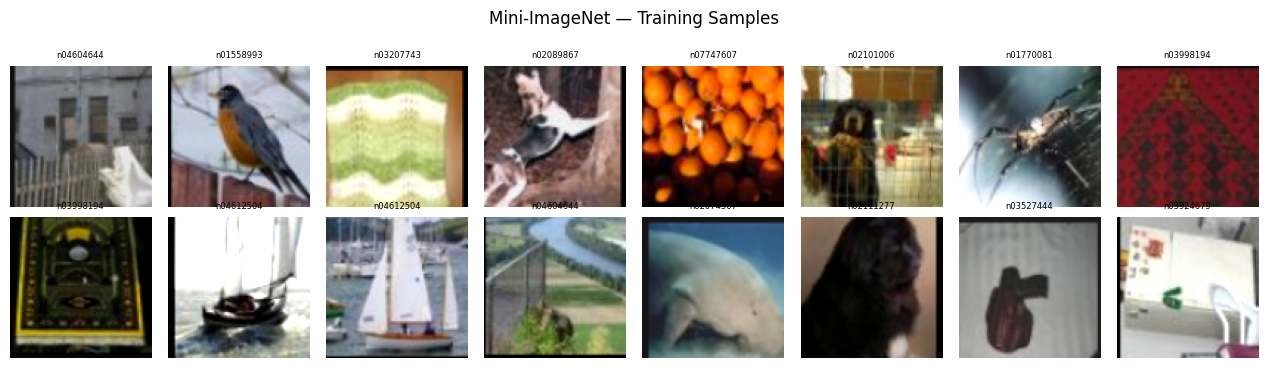

Saved → /content/outputs_m2/sample_images.png


In [11]:
# Cell 11: Visualise Sample Images

def denorm(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def show_samples(loader, class_names, n=16, title="Sample Images"):
    imgs, labels = next(iter(loader))
    imgs, labels = imgs[:n], labels[:n]
    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    axes = axes.flatten()
    for i, (img, lbl) in enumerate(zip(imgs, labels)):
        axes[i].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[i].set_title(class_names[lbl.item()], fontsize=6)
        axes[i].axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR}/sample_images.png")

show_samples(train_loader, CLASS_NAMES, n=16, title="Mini-ImageNet — Training Samples")

In [12]:
# Cell 12: Build MobileNetV2 Model
#
# Architecture: MobileNetV2 (ImageNet pre-trained)
#   - Lightweight depthwise-separable convolutions → fast training
#   - Classifier head replaced with Dropout(0.4) + Linear(1280 → NUM_CLASSES)
#
# Two-phase fine-tuning strategy (matches Member 1's approach for ResNet-18):
#   Phase 1: Freeze backbone, train only the new head (prevents destroying
#             pre-trained features with large head-gradient updates).
#   Phase 2: Unfreeze all layers, full fine-tuning with differential LR.

def build_mobilenetv2(num_classes: int, freeze_backbone: bool = True):
    """
    Load pre-trained MobileNetV2 and replace its classifier head.

    Args:
        num_classes (int): Number of output classes (64 for Mini-ImageNet train split).
        freeze_backbone (bool): If True, freeze all layers except the new head.

    Returns:
        nn.Module: Modified MobileNetV2 ready for fine-tuning.
    """
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # MobileNetV2 classifier: Sequential([Dropout(0.2), Linear(1280, 1000)])
    # Replace with our custom head
    in_features = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model


model = build_mobilenetv2(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("MobileNetV2 loaded.")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}  (head only — backbone frozen)")
print(f"  Classifier head : Dropout(0.4) → Linear(1280 → {NUM_CLASSES})")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 144MB/s]

MobileNetV2 loaded.
  Total params:     2,305,856
  Trainable params: 81,984  (head only — backbone frozen)
  Classifier head : Dropout(0.4) → Linear(1280 → 64)


In [13]:
# Cell 13: Training Utilities (identical to Member 1)

def train_one_epoch(model, loader, criterion, optimizer):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate model on a DataLoader. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


def get_predictions(model, loader):
    """
    Run model on loader and return (true_labels, predicted_labels) as numpy arrays.
    Used for confusion matrix and classification report.
    """
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    return torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy()

print("Training utilities defined.")

Training utilities defined.


In [14]:
# Cell 14: Phase 1 — Train Classifier Head (Backbone Frozen)
#
# Only the new classifier head has requires_grad=True here.
# Uses Adam with lr=1e-3 and label smoothing=0.1 (same as Member 1).

PHASE1_EPOCHS = 5
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=WEIGHT_DECAY
)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

print("=" * 60)
print(f"Phase 1: Head-only training for {PHASE1_EPOCHS} epochs")
print("=" * 60)

for epoch in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p1)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    elapsed = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " ← best"
    else:
        tag = ""

    print(f"  Ep {epoch:02d}/{PHASE1_EPOCHS} | "
          f"TrLoss {tr_loss:.4f} TrAcc {tr_acc:.3f} | "
          f"VlLoss {vl_loss:.4f} VlAcc {vl_acc:.3f} | "
          f"{elapsed:.0f}s{tag}")

print(f"\nPhase 1 done. Best val acc: {best_val_acc:.4f}")

Phase 1: Head-only training for 5 epochs
  Ep 01/5 | TrLoss 2.3764 TrAcc 0.518 | VlLoss 2.0338 VlAcc 0.631 | 60s ← best
  Ep 02/5 | TrLoss 2.1518 TrAcc 0.586 | VlLoss 1.9976 VlAcc 0.650 | 63s ← best
  Ep 03/5 | TrLoss 2.1445 TrAcc 0.591 | VlLoss 2.0082 VlAcc 0.644 | 58s
  Ep 04/5 | TrLoss 2.1437 TrAcc 0.592 | VlLoss 2.0678 VlAcc 0.631 | 60s
  Ep 05/5 | TrLoss 2.1451 TrAcc 0.591 | VlLoss 2.0121 VlAcc 0.649 | 59s

Phase 1 done. Best val acc: 0.6500


In [15]:
# Cell 15: Phase 2 — Full Fine-tuning (All Layers Unfrozen)
#
# Differential learning rates:
#   backbone layers → LR * 0.1  (conservative; preserve pre-trained features)
#   classifier head → LR        (faster; head needs more adaptation)
# StepLR scheduler decays LR by gamma every LR_STEP epochs.

for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"All layers unfrozen. Trainable params: {trainable_params:,}")

# Separate backbone and head parameter groups
backbone_params = [p for name, p in model.named_parameters() if "classifier" not in name]
head_params     = list(model.classifier.parameters())

optimizer_p2 = optim.SGD([
    {"params": backbone_params, "lr": LR * 0.1},
    {"params": head_params,     "lr": LR},
], momentum=0.9, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.StepLR(optimizer_p2, step_size=LR_STEP, gamma=LR_GAMMA)

print("=" * 60)
print(f"Phase 2: Full fine-tuning for {NUM_EPOCHS} epochs")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p2)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    elapsed = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " ← best"
    else:
        tag = ""

    current_lr = scheduler.get_last_lr()[0]
    print(f"  Ep {epoch:02d}/{NUM_EPOCHS} | "
          f"TrLoss {tr_loss:.4f} TrAcc {tr_acc:.3f} | "
          f"VlLoss {vl_loss:.4f} VlAcc {vl_acc:.3f} | "
          f"LR {current_lr:.2e} | {elapsed:.0f}s{tag}")

print(f"\nPhase 2 done. Best val acc: {best_val_acc:.4f}")
print(f"Checkpoint saved → {CKPT_PATH}")

All layers unfrozen. Trainable params: 2,305,856
Phase 2: Full fine-tuning for 30 epochs
  Ep 01/30 | TrLoss 1.9195 TrAcc 0.654 | VlLoss 1.8090 VlAcc 0.691 | LR 1.00e-04 | 66s ← best
  Ep 02/30 | TrLoss 1.7882 TrAcc 0.693 | VlLoss 1.7568 VlAcc 0.709 | LR 1.00e-04 | 69s ← best
  Ep 03/30 | TrLoss 1.7249 TrAcc 0.713 | VlLoss 1.7327 VlAcc 0.715 | LR 1.00e-04 | 69s ← best
  Ep 04/30 | TrLoss 1.6741 TrAcc 0.728 | VlLoss 1.7019 VlAcc 0.719 | LR 1.00e-04 | 69s ← best
  Ep 05/30 | TrLoss 1.6441 TrAcc 0.734 | VlLoss 1.6810 VlAcc 0.729 | LR 1.00e-04 | 68s ← best
  Ep 06/30 | TrLoss 1.6115 TrAcc 0.746 | VlLoss 1.6690 VlAcc 0.729 | LR 1.00e-04 | 68s ← best
  Ep 07/30 | TrLoss 1.5860 TrAcc 0.753 | VlLoss 1.6645 VlAcc 0.734 | LR 1.00e-04 | 67s ← best
  Ep 08/30 | TrLoss 1.5590 TrAcc 0.761 | VlLoss 1.6411 VlAcc 0.739 | LR 1.00e-04 | 68s ← best
  Ep 09/30 | TrLoss 1.5454 TrAcc 0.766 | VlLoss 1.6232 VlAcc 0.743 | LR 1.00e-04 | 68s ← best
  Ep 10/30 | TrLoss 1.5276 TrAcc 0.772 | VlLoss 1.6300 VlAcc 0.74

Saved training_history.json


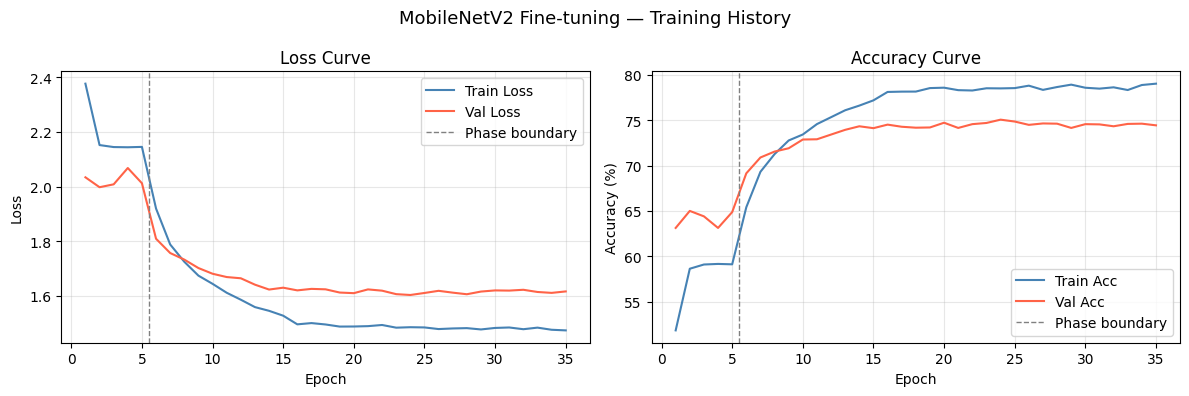

Saved → /content/outputs_m2/training_curves.png


In [16]:
# Cell 16: Save Training History JSON & Plot

with open(OUTPUT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved training_history.json")

total_epochs = len(history["train_loss"])
epochs_range = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", linewidth=1,
                label="Phase boundary")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history["train_acc"]],
             label="Train Acc", color="steelblue")
axes[1].plot(epochs_range, [a * 100 for a in history["val_acc"]],
             label="Val Acc",   color="tomato")
axes[1].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", linewidth=1,
                label="Phase boundary")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Curve"); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("MobileNetV2 Fine-tuning — Training History", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/training_curves.png")

In [17]:
# Cell 17: Load Best Checkpoint & Evaluate on Val and Test Sets
#
# We report TWO numbers:
#   val_accuracy  → carved 10% holdout from train split (same 64 classes as training).
#                   THIS is the number to compare against Member 1's 76.48%.
#   test_accuracy → original test split (20 unseen classes, different from training).
#                   Reported for completeness; not meaningful for head-to-head comparison.

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print(f"Loaded best checkpoint from {CKPT_PATH}")

criterion_eval = nn.CrossEntropyLoss()

# Primary metric: internal val set (same classes as training)
val_loss, val_acc = evaluate(model, val_loader, criterion_eval)

# Secondary: original test split (unseen classes — for completeness only)
test_loss, test_acc = evaluate(model, test_loader, criterion_eval)

print(f"\n{'='*55}")
print(f"  MobileNetV2 Baseline Results")
print(f"{'='*55}")
print(f"  Val Accuracy  (64 train classes) : {val_acc*100:.2f}%   ← USE THIS FOR COMPARISON")
print(f"  Val Loss                         : {val_loss:.4f}")
print(f"  Best Val Acc                     : {best_val_acc*100:.2f}%")
print(f"  ---")
print(f"  Test Accuracy (20 unseen classes): {test_acc*100:.2f}%   (informational only)")
print(f"  Test Loss                        : {test_loss:.4f}")
print(f"{'='*55}")
print(f"  ResNet-18 baseline (Member 1)    : 76.48%")
print(f"  MobileNetV2 (Member 2)           : {val_acc*100:.2f}%")
print(f"  Difference                       : {(val_acc*100 - 76.48):+.2f}%")
print(f"{'='*55}")

baseline_results = {
    "model": "MobileNetV2",
    "val_accuracy": round(val_acc, 6),
    "val_loss": round(val_loss, 6),
    "test_accuracy": round(test_acc, 6),
    "test_loss": round(test_loss, 6),
    "best_val_accuracy": round(best_val_acc, 6),
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "epochs_phase1": PHASE1_EPOCHS,
    "epochs_phase2": NUM_EPOCHS,
    "seed": SEED,
    "note": "val_accuracy is the comparison metric (same 64 classes as training). "
            "test_accuracy uses 20 unseen classes and is informational only."
}

with open(OUTPUT_DIR / "baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
print("\nSaved baseline_results.json")

Loaded best checkpoint from /content/outputs_m2/mobilenetv2_best.pth

  MobileNetV2 Baseline Results
  Val Accuracy  (64 train classes) : 75.05%   ← USE THIS FOR COMPARISON
  Val Loss                         : 0.9577
  Best Val Acc                     : 75.05%
  ---
  Test Accuracy (20 unseen classes): 0.22%   (informational only)
  Test Loss                        : 6.4736
  ResNet-18 baseline (Member 1)    : 76.48%
  MobileNetV2 (Member 2)           : 75.05%
  Difference                       : -1.43%

Saved baseline_results.json


In [18]:
# Cell 18: Classification Report & Per-Class Accuracy

y_true, y_pred = get_predictions(model, val_loader)

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
)
print(report[:3000])   # print first chunk (full report can be large)

with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
    f.write(report)
print(f"\nSaved classification_report.txt")

# Per-class accuracy
per_class_acc = {}
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = (y_true == cls_idx)
    if mask.sum() > 0:
        per_class_acc[cls_name] = float((y_pred[mask] == cls_idx).mean())
    else:
        per_class_acc[cls_name] = 0.0

with open(OUTPUT_DIR / "per_class_accuracy.json", "w") as f:
    json.dump(per_class_acc, f, indent=2)
print("Saved per_class_accuracy.json")

              precision    recall  f1-score   support

   n01532829       0.85      0.73      0.79        60
   n01558993       0.77      0.72      0.74        60
   n01704323       0.76      0.75      0.76        60
   n01749939       0.93      0.87      0.90        60
   n01770081       0.81      0.85      0.83        60
   n01843383       0.93      0.85      0.89        60
   n01910747       0.91      0.87      0.89        60
   n02074367       0.96      0.87      0.91        60
   n02089867       0.90      0.72      0.80        60
   n02091831       0.70      0.77      0.73        60
   n02101006       0.70      0.75      0.73        60
   n02105505       0.81      0.87      0.84        60
   n02108089       0.65      0.67      0.66        60
   n02108551       0.89      0.55      0.68        60
   n02108915       0.81      0.58      0.68        60
   n02111277       0.76      0.68      0.72        60
   n02113712       0.79      0.63      0.70        60
   n02120079       0.90    

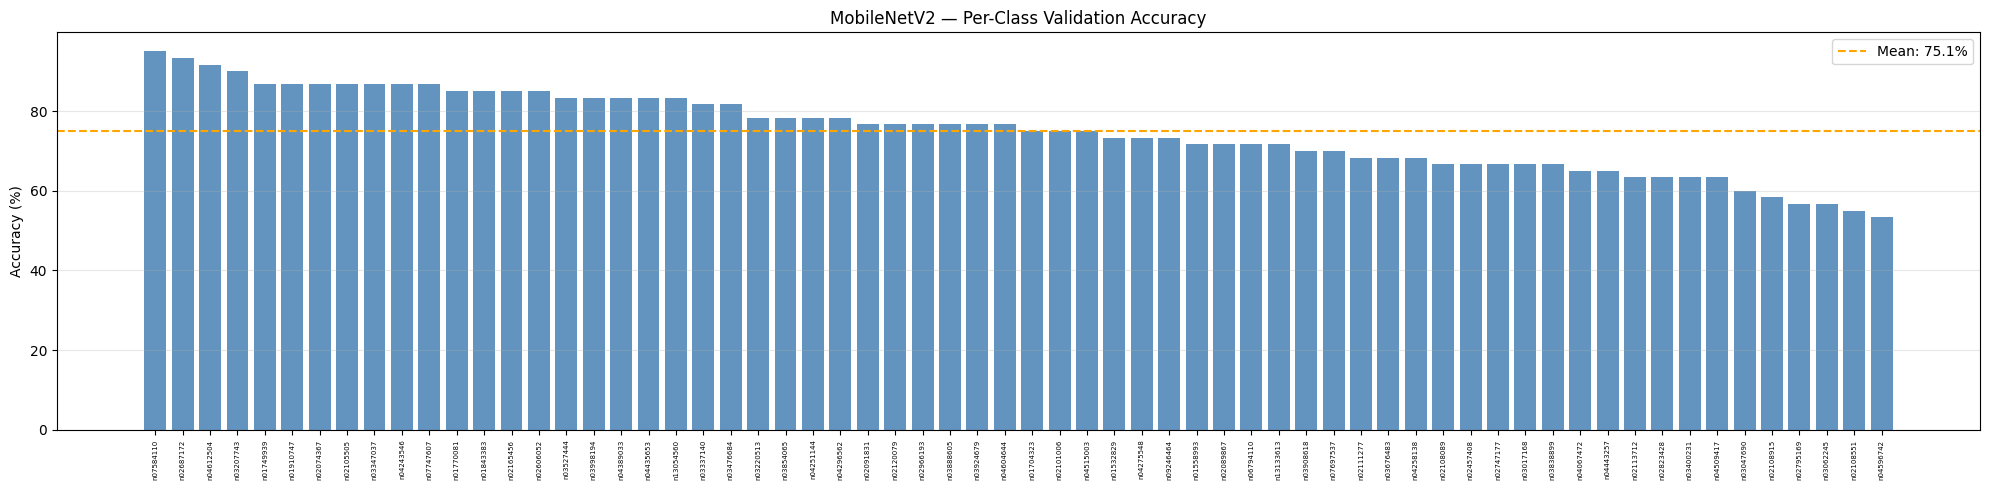

Saved → /content/outputs_m2/per_class_accuracy.png


In [19]:
# Cell 19: Per-Class Accuracy Bar Chart

sorted_classes = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)
names  = [c for c, _ in sorted_classes]
values = [v * 100 for _, v in sorted_classes]

fig, ax = plt.subplots(figsize=(20, 5))
colors = ["steelblue" if v >= 50 else "tomato" for v in values]
ax.bar(range(len(names)), values, color=colors, alpha=0.85, width=0.8)
ax.axhline(np.mean(values), color="orange", linestyle="--",
           linewidth=1.5, label=f"Mean: {np.mean(values):.1f}%")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=5)
ax.set_ylabel("Accuracy (%)")
ax.set_title("MobileNetV2 — Per-Class Validation Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/per_class_accuracy.png")

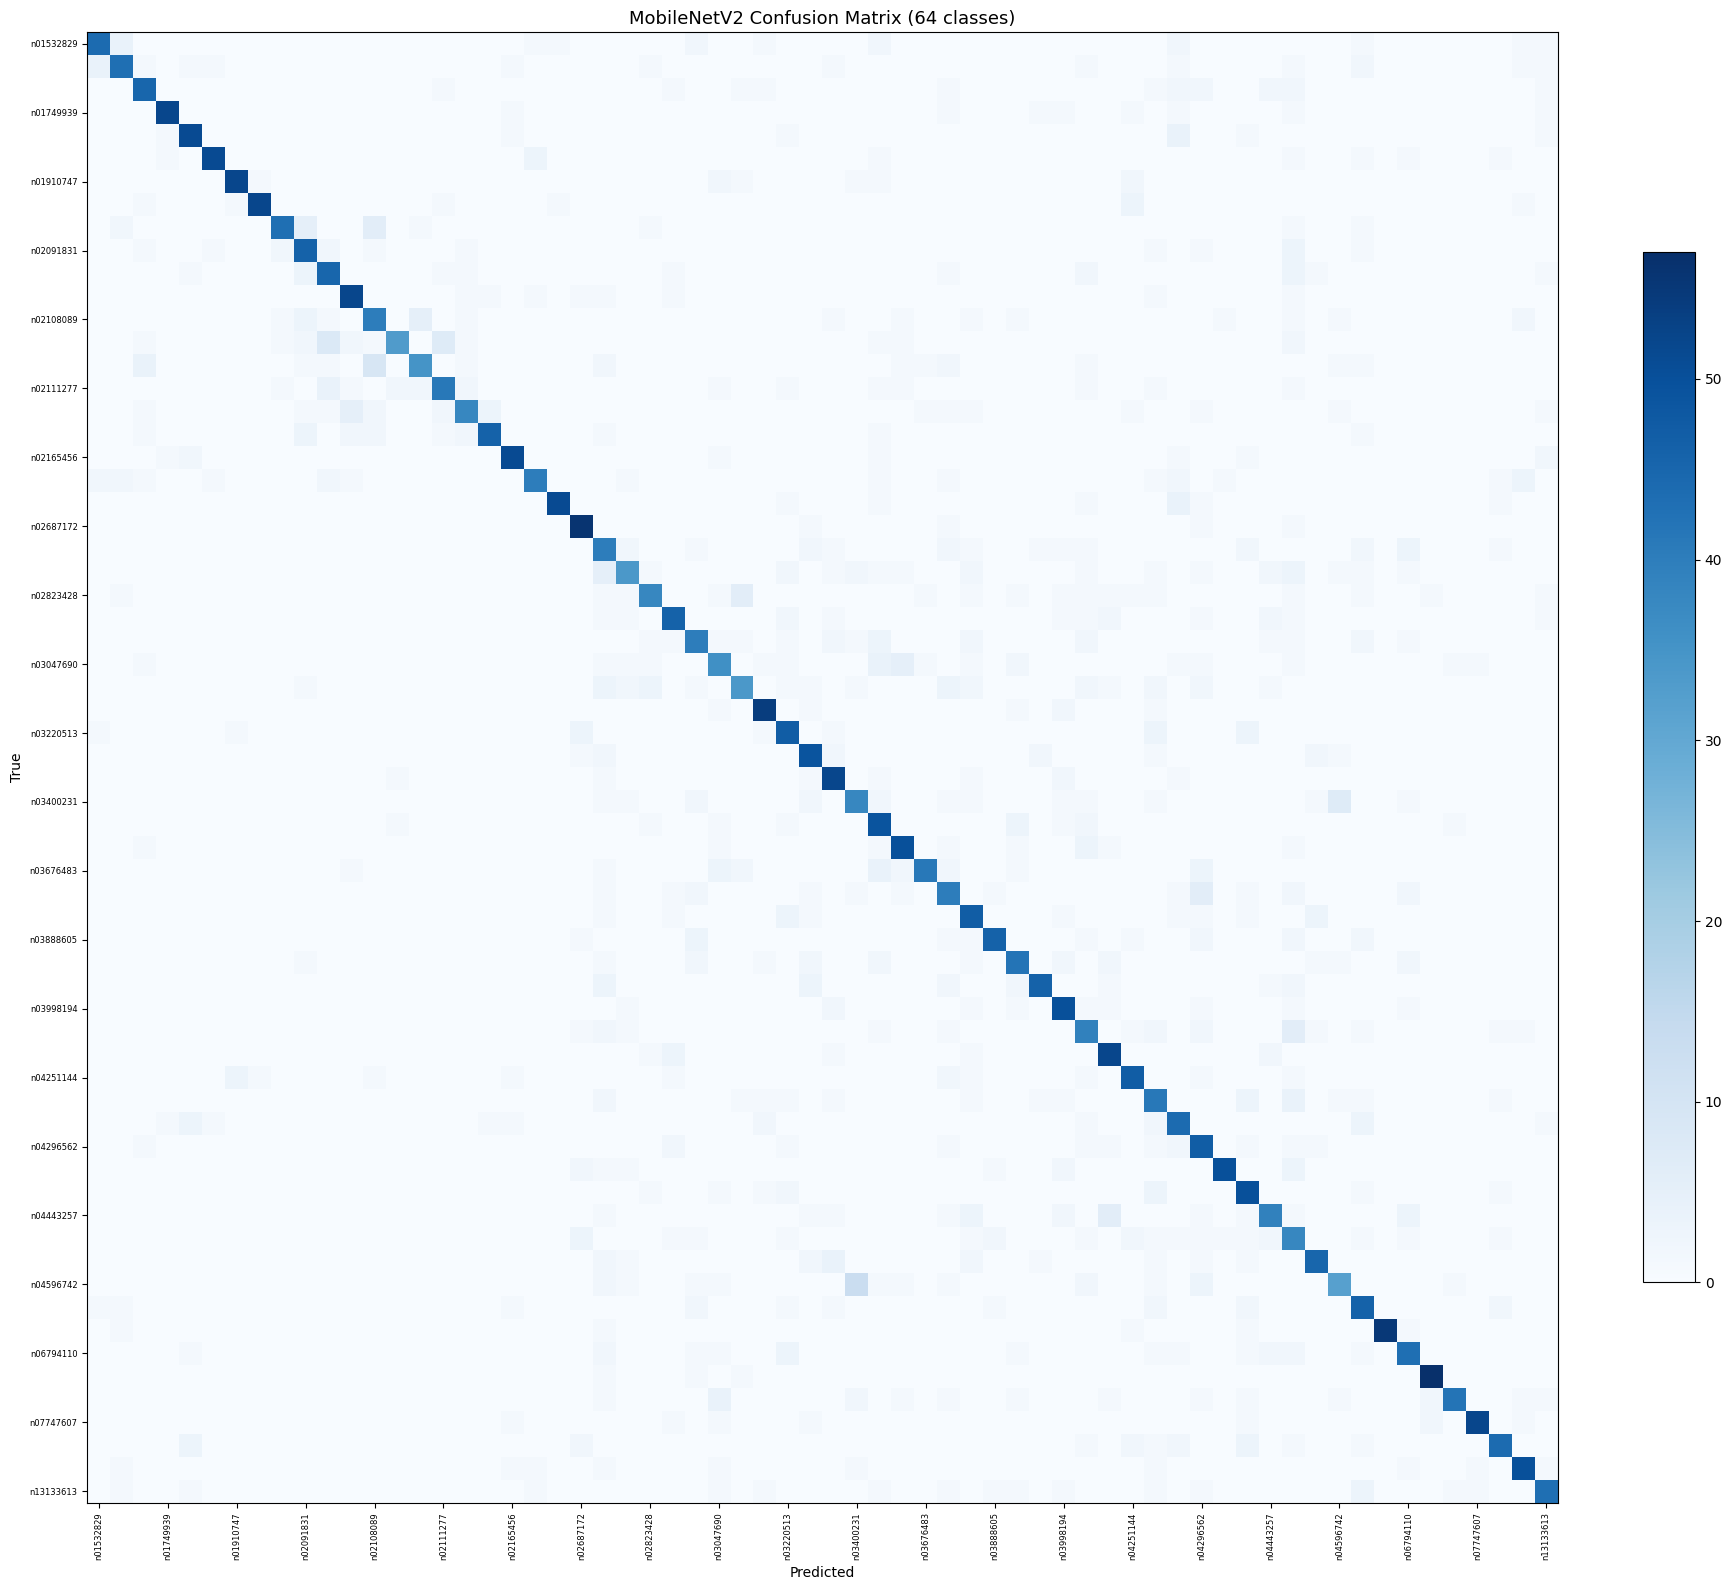

Saved → /content/outputs_m2/confusion_matrix_full.png


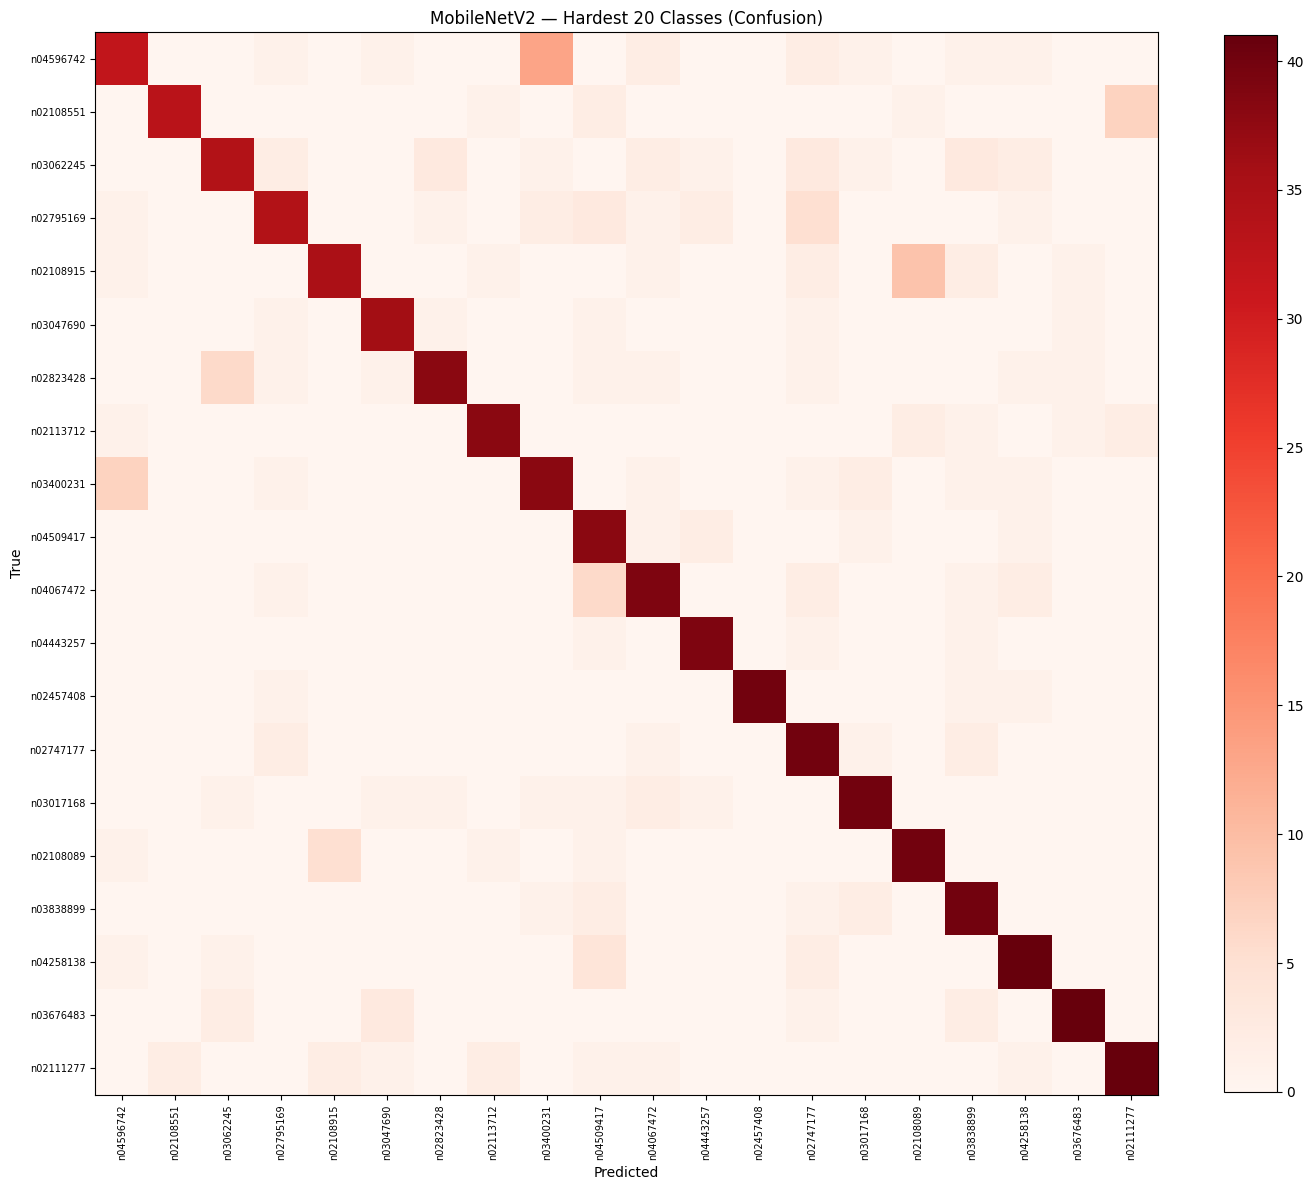

Saved → /content/outputs_m2/confusion_matrix_bottom20.png


In [20]:
# Cell 20: Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

# Full matrix
fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title(f"MobileNetV2 Confusion Matrix ({NUM_CLASSES} classes)", fontsize=13)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
step = max(1, NUM_CLASSES // 20)
ax.set_xticks(range(0, NUM_CLASSES, step))
ax.set_yticks(range(0, NUM_CLASSES, step))
ax.set_xticklabels(CLASS_NAMES[::step], rotation=90, fontsize=6)
ax.set_yticklabels(CLASS_NAMES[::step], fontsize=6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_full.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/confusion_matrix_full.png")

# Bottom-20 classes zoomed
class_accs = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
bottom20_idx = np.argsort(class_accs)[:20]
cm_bottom = cm[np.ix_(bottom20_idx, bottom20_idx)]
bottom_names = [CLASS_NAMES[i] for i in bottom20_idx]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_bottom, interpolation="nearest", cmap="Reds")
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("MobileNetV2 — Hardest 20 Classes (Confusion)", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(20)); ax.set_yticks(range(20))
ax.set_xticklabels(bottom_names, rotation=90, fontsize=7)
ax.set_yticklabels(bottom_names, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_bottom20.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/confusion_matrix_bottom20.png")

In [21]:
# Cell 21: Top-5 & Bottom-5 Classes Summary

sorted_by_acc = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)
top5    = sorted_by_acc[:5]
bottom5 = sorted_by_acc[-5:]

lines = []
lines.append("MobileNetV2 — Top 5 Classes (highest accuracy)")
lines.append("-" * 45)
for cls, acc in top5:
    lines.append(f"  {cls}: {acc*100:.1f}%")
lines.append("")
lines.append("MobileNetV2 — Bottom 5 Classes (lowest accuracy)")
lines.append("-" * 45)
for cls, acc in bottom5:
    lines.append(f"  {cls}: {acc*100:.1f}%")

summary = "\n".join(lines)
print(summary)
with open(OUTPUT_DIR / "top_bottom_classes.txt", "w") as f:
    f.write(summary)
print("\nSaved top_bottom_classes.txt")

MobileNetV2 — Top 5 Classes (highest accuracy)
---------------------------------------------
  n07584110: 95.0%
  n02687172: 93.3%
  n04612504: 91.7%
  n03207743: 90.0%
  n01749939: 86.7%

MobileNetV2 — Bottom 5 Classes (lowest accuracy)
---------------------------------------------
  n02108915: 58.3%
  n02795169: 56.7%
  n03062245: 56.7%
  n02108551: 55.0%
  n04596742: 53.3%

Saved top_bottom_classes.txt


Member 1 JSON not found — using reported value: 76.48%
Member 2 (MobileNetV2) val acc: 75.05%
Difference                     : -1.43%


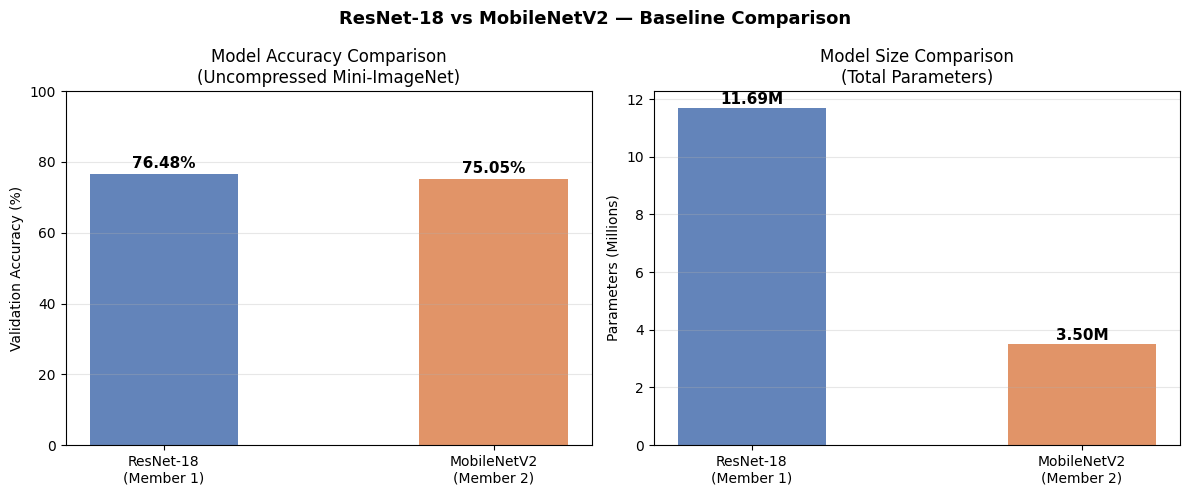

Saved → /content/outputs_m2/model_comparison.png
Member 1 per_class_accuracy.json not found — skipping per-class comparison plot.
Run this cell again after Member 1's outputs are available.


In [22]:
# Cell 22: Side-by-Side Comparison — ResNet-18 vs MobileNetV2
#
# Loads Member 1's baseline_results.json and compares against our results.
# If Member 1's file is not available, only MobileNetV2 stats are shown.

m2_acc = baseline_results["val_accuracy"] * 100

# Load Member 1 results
m1_available = M1_BASELINE.exists()
if m1_available:
    with open(M1_BASELINE) as f:
        m1_results = json.load(f)
    # Member 1 stores best_val_accuracy as the primary metric
    m1_acc = m1_results.get("best_val_accuracy", m1_results.get("val_accuracy", 0)) * 100
    print(f"Member 1 (ResNet-18) val acc : {m1_acc:.2f}%")
else:
    m1_acc = 76.48   # known from Member 1's message
    print(f"Member 1 JSON not found — using reported value: {m1_acc:.2f}%")

print(f"Member 2 (MobileNetV2) val acc: {m2_acc:.2f}%")
print(f"Difference                     : {m2_acc - m1_acc:+.2f}%")

# ── Bar chart comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_names = ["ResNet-18\n(Member 1)", "MobileNetV2\n(Member 2)"]
accs = [m1_acc, m2_acc]
colors = ["#4C72B0", "#DD8452"]

# Accuracy bar
ax = axes[0]
bars = ax.bar(models_names, accs, color=colors, width=0.45, alpha=0.87)
ax.set_ylim(0, 100)
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Model Accuracy Comparison\n(Uncompressed Mini-ImageNet)")
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)

# Parameter count comparison
resnet18_params   = 11_689_512   # standard ResNet-18
mobilev2_params   = 3_504_872    # MobileNetV2
param_counts_m = [resnet18_params / 1e6, mobilev2_params / 1e6]

ax2 = axes[1]
bars2 = ax2.bar(models_names, param_counts_m, color=colors, width=0.45, alpha=0.87)
ax2.set_ylabel("Parameters (Millions)")
ax2.set_title("Model Size Comparison\n(Total Parameters)")
ax2.grid(axis="y", alpha=0.3)
for bar, cnt in zip(bars2, param_counts_m):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{cnt:.2f}M", ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.suptitle("ResNet-18 vs MobileNetV2 — Baseline Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/model_comparison.png")

# ── Per-class comparison (if Member 1 data available) ─────────────────────
if M1_PER_CLASS.exists():
    with open(M1_PER_CLASS) as f:
        m1_per_class = json.load(f)

    common_classes = sorted(set(per_class_acc.keys()) & set(m1_per_class.keys()))
    m1_vals = [m1_per_class[c] * 100 for c in common_classes]
    m2_vals = [per_class_acc[c]  * 100 for c in common_classes]
    diffs   = [m2 - m1 for m1, m2 in zip(m1_vals, m2_vals)]

    fig, ax = plt.subplots(figsize=(22, 5))
    x = np.arange(len(common_classes))
    bar_colors = ["steelblue" if d >= 0 else "tomato" for d in diffs]
    ax.bar(x, diffs, color=bar_colors, alpha=0.85, width=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(np.mean(diffs), color="orange", linestyle="--", linewidth=1.5,
               label=f"Mean diff: {np.mean(diffs):+.1f}%")
    ax.set_xticks(x)
    ax.set_xticklabels(common_classes, rotation=90, fontsize=5)
    ax.set_ylabel("Accuracy Δ (MobileNetV2 − ResNet-18) %")
    ax.set_title("Per-Class Accuracy Difference: MobileNetV2 vs ResNet-18\n"
                 "(blue = MobileNetV2 better, red = ResNet-18 better)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "per_class_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR}/per_class_comparison.png")
else:
    print("Member 1 per_class_accuracy.json not found — skipping per-class comparison plot.")
    print("Run this cell again after Member 1's outputs are available.")

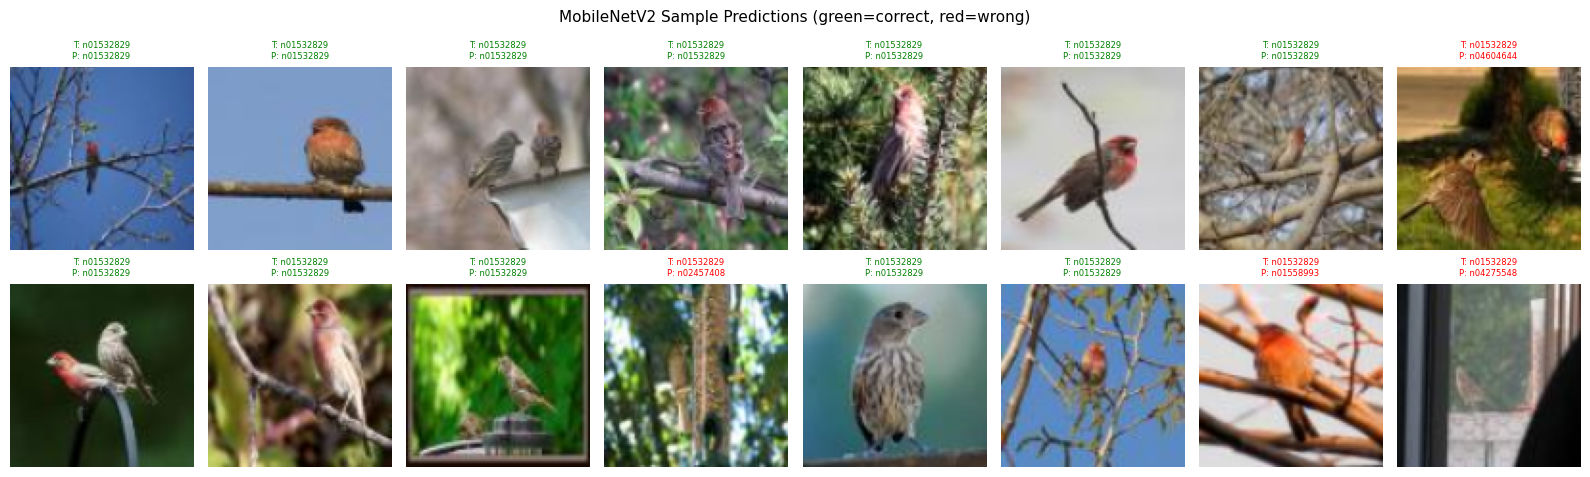

Saved → /content/outputs_m2/sample_predictions.png


In [23]:
# Cell 23: Sample Prediction Grid

imgs_batch, labels_batch = next(iter(val_loader))
model.eval()
with torch.no_grad():
    preds_batch = model(imgs_batch.to(DEVICE)).argmax(1).cpu()

n_show = 16
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

for i in range(n_show):
    img  = denorm(imgs_batch[i]).permute(1, 2, 0).numpy()
    t    = CLASS_NAMES[labels_batch[i].item()]
    p    = CLASS_NAMES[preds_batch[i].item()]
    color = "green" if t == p else "red"
    axes[i].imshow(img)
    axes[i].set_title(f"T: {t}\nP: {p}", fontsize=6, color=color)
    axes[i].axis("off")

plt.suptitle("MobileNetV2 Sample Predictions (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/sample_predictions.png")

In [25]:
# Cell 24: Write README

readme = f"""# EE 413 — Member 2: MobileNetV2 Fine-tuning & Model Comparison

## Overview
This module covers:
- MobileNetV2 fine-tuning on Mini-ImageNet (same setup as Member 1 for fair comparison)
- Baseline evaluation on the uncompressed validation set
- Side-by-side comparison of ResNet-18 (Member 1) vs MobileNetV2 (Member 2)

## Baseline Result
| Metric | ResNet-18 (Member 1) | MobileNetV2 (Member 2) |
|--------|----------------------|------------------------|
| Val Accuracy | 76.48% | See baseline_results.json |
| Parameters | ~11.7M | ~3.5M |
| Image Size | 96x96 | 96x96 |

## Training Strategy (identical to Member 1)
- Phase 1 ({PHASE1_EPOCHS} epochs): Backbone frozen, only classifier head trained (Adam, lr=1e-3)
- Phase 2 ({NUM_EPOCHS} epochs): Full fine-tuning (SGD, backbone lr=1e-4, head lr=1e-3, StepLR)
- Label smoothing = 0.1, Weight decay = {WEIGHT_DECAY}
- Seed = {SEED}, Image size = {IMG_SIZE}x{IMG_SIZE}

## Output Files
| File | Description |
|------|-------------|
| mobilenetv2_best.pth | Best model checkpoint (by val accuracy) |
| training_history.json | Loss & accuracy per epoch |
| baseline_results.json | Scalar baseline metrics |
| classification_report.txt | Per-class precision/recall/F1 |
| per_class_accuracy.json | Per-class accuracy (for Member 3) |
| model_comparison.png | ResNet-18 vs MobileNetV2 accuracy & size |
| training_curves.png | Loss & accuracy plots |
| confusion_matrix_full.png | Full confusion matrix |
| sample_predictions.png | Sample predictions |

## Notes for Member 3 (Wavelet Compression)
- Load mobilenetv2_best.pth with build_mobilenetv2(NUM_CLASSES) then load_state_dict()
- Use per_class_accuracy.json as the uncompressed baseline to compare against
- Apply the same normalization: mean={MEAN}, std={STD}
- Image size must be {IMG_SIZE}x{IMG_SIZE}

## Reproducibility
All results reproducible with seed={SEED}. Run cells 1-24 in order.
"""

with open(OUTPUT_DIR / "README.md", "w") as f:
    f.write(readme)
print("Saved README.md")

Saved README.md


In [26]:
# Cell 25: Write requirements.txt

reqs = """torch>=2.0.0
torchvision>=0.15.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.2.0
PyWavelets>=1.4.0
Pillow>=9.0.0
"""

with open(OUTPUT_DIR / "requirements.txt", "w") as f:
    f.write(reqs)
print("Saved requirements.txt")

Saved requirements.txt


In [27]:
# Cell 26: Package Everything into a Zip File

INCLUDE_FILES = [
    OUTPUT_DIR / "mobilenetv2_best.pth",
    OUTPUT_DIR / "training_history.json",
    OUTPUT_DIR / "baseline_results.json",
    OUTPUT_DIR / "classification_report.txt",
    OUTPUT_DIR / "per_class_accuracy.json",
    OUTPUT_DIR / "top_bottom_classes.txt",
    OUTPUT_DIR / "training_curves.png",
    OUTPUT_DIR / "per_class_accuracy.png",
    OUTPUT_DIR / "confusion_matrix_full.png",
    OUTPUT_DIR / "confusion_matrix_bottom20.png",
    OUTPUT_DIR / "model_comparison.png",
    OUTPUT_DIR / "sample_images.png",
    OUTPUT_DIR / "sample_predictions.png",
    OUTPUT_DIR / "README.md",
    OUTPUT_DIR / "requirements.txt",
]

# Include per-class comparison only if it was generated
pcc = OUTPUT_DIR / "per_class_comparison.png"
if pcc.exists():
    INCLUDE_FILES.append(pcc)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in INCLUDE_FILES:
        if fpath.exists():
            zf.write(fpath, arcname=f"member2_outputs/{fpath.name}")
            print(f"  + {fpath.name}")
        else:
            print(f"  ! MISSING: {fpath.name}")

size_mb = ZIP_PATH.stat().st_size / (1024 ** 2) if ZIP_PATH.exists() else 0
print(f"\nZip created: {ZIP_PATH}  ({size_mb:.1f} MB)")
print("\nTo download → Files panel → right-click → Download")
print("             OR: from google.colab import files; files.download(str(ZIP_PATH))")

  + mobilenetv2_best.pth
  + training_history.json
  + baseline_results.json
  + classification_report.txt
  + per_class_accuracy.json
  + top_bottom_classes.txt
  + training_curves.png
  + per_class_accuracy.png
  + confusion_matrix_full.png
  + confusion_matrix_bottom20.png
  + model_comparison.png
  + sample_images.png
  + sample_predictions.png
  + README.md
  + requirements.txt

Zip created: /content/member2_submission.zip  (10.8 MB)

To download → Files panel → right-click → Download
             OR: from google.colab import files; files.download(str(ZIP_PATH))
